# Customer Churn Prediction

Predicting whether a telecom customer will leave (churn) or stay, using machine learning.

**Dataset:** Telco Customer Churn (7,043 customers, 20 features) — loaded directly from a public URL, no download needed.

**What this notebook covers:**
- Data loading & cleaning
- Exploratory Data Analysis (EDA)
- Encoding & feature scaling
- Training two models (Logistic Regression & Random Forest)
- Comparing them with accuracy, confusion matrix, classification report and ROC-AUC
- Finding which factors drive churn the most

## 1. Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Loading the data

The CSV is read straight from a public GitHub URL, so the notebook runs anywhere (including Colab) without uploading any file.

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


`TotalCharges` shows up as `object` (text) instead of a number — that usually means some values are not valid numbers. Let's fix that in the cleaning step.

## 3. Data cleaning

- Convert `TotalCharges` to numeric (invalid entries become NaN)
- Fill those NaNs with the median
- Drop `customerID` since it's just an identifier, not a feature

In [4]:
# convert to numeric, bad values become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values in TotalCharges:", df["TotalCharges"].isnull().sum())

# 11 rows are customers with tenure = 0, so median fill is safe
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# ID column has no predictive value
df = df.drop("customerID", axis=1)
print("Cleaned shape:", df.shape)

Missing values in TotalCharges: 11
Cleaned shape: (7043, 20)


## 4. Exploratory Data Analysis (EDA)

First, check how balanced the target column is.

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


/tmp/ipykernel_1437/811258943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


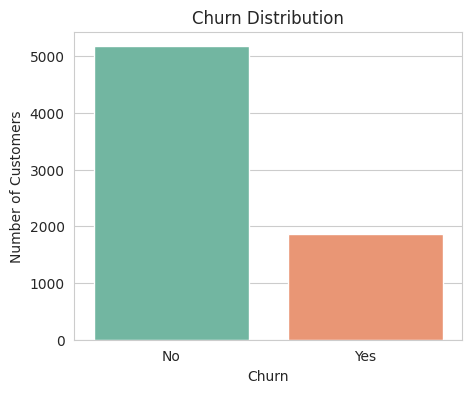

In [5]:
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print(churn_pct.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Churn Distribution")
plt.ylabel("Number of Customers")
plt.show()

About **26.5%** of customers churn — the classes are somewhat imbalanced, so accuracy alone won't be enough. I'll also look at precision, recall and ROC-AUC later.

### How do numeric features relate to churn?

/tmp/ipykernel_1437/1619011472.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set2", ax=axes[1])


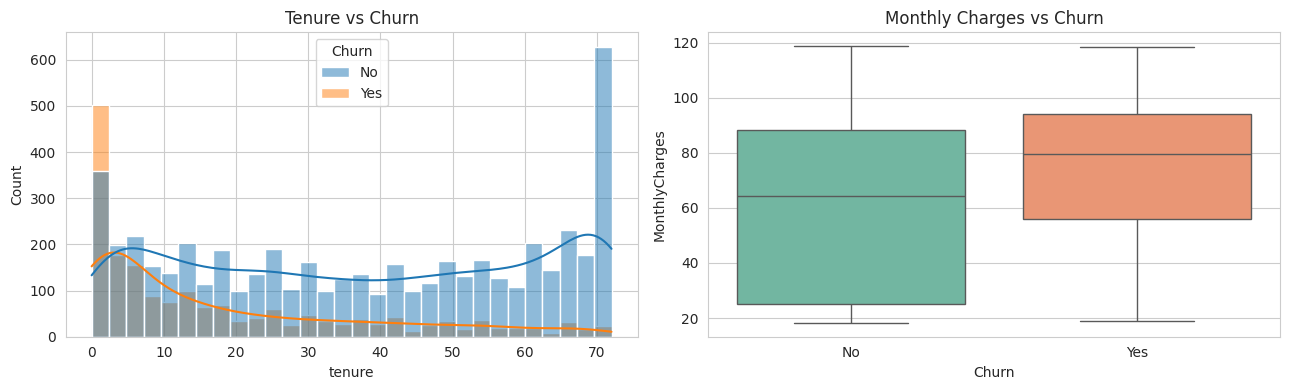

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set2", ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")

plt.tight_layout()
plt.show()

Customers with **low tenure** (new customers) and **higher monthly charges** churn more.

### Contract type vs churn

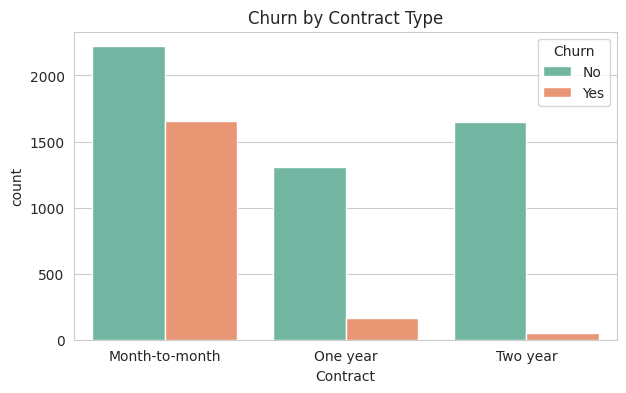

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(x="Contract", hue="Churn", data=df, palette="Set2")
plt.title("Churn by Contract Type")
plt.show()

Month-to-month contracts churn far more than one/two-year contracts — makes sense, long-term contracts lock customers in.

## 5. Encoding & scaling

- Convert the target `Churn` to 1/0
- One-hot encode the categorical columns
- Scale the numeric columns so no feature dominates just because of its range

In [8]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

cat_cols = df.select_dtypes(include='object').columns
print("Categorical columns:", len(cat_cols))

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df.shape)

Categorical columns: 15
Shape after encoding: (7043, 31)


In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# stratify keeps the same churn ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5634, 30) | Test: (1409, 30)


In [10]:
scaler = StandardScaler()
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# fit on train only, then transform both (avoids data leakage)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.102371,-0.521976,-0.263289,True,False,False,False,True,False,...,False,True,False,True,False,False,False,False,True,False
3151,0,-0.711743,0.337478,-0.504814,True,True,True,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4860,0,-0.793155,-0.809013,-0.751213,True,True,True,False,True,False,...,False,False,False,False,False,True,False,False,False,True
3867,0,-0.263980,0.284384,-0.173699,False,True,False,True,False,False,...,False,True,False,True,False,True,True,True,False,False
3810,0,-1.281624,-0.676279,-0.990851,True,True,True,True,False,False,...,False,False,False,False,False,False,False,False,True,False


## 6. Model training

Trying two models to compare a simple baseline with an ensemble method:
1. **Logistic Regression** — simple, interpretable baseline
2. **Random Forest** — captures non-linear patterns and gives feature importance

In [11]:
# 1) Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

lr_pred = log_reg.predict(X_test)
lr_prob = log_reg.predict_proba(X_test)[:, 1]

# 2) Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

## 7. Model evaluation

In [12]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, lr_pred), accuracy_score(y_test, rf_pred)],
    "ROC-AUC": [roc_auc_score(y_test, lr_prob), roc_auc_score(y_test, rf_prob)],
}).round(4)
results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.8055,0.8421
1,Random Forest,0.7857,0.8246


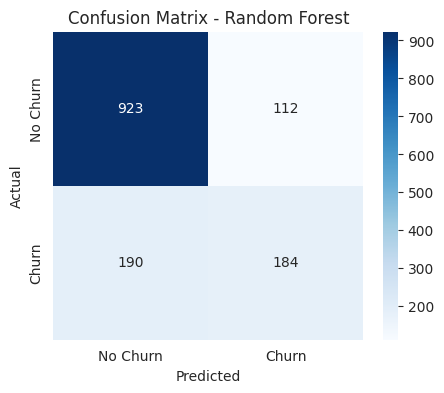

In [13]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
print(classification_report(y_test, rf_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



Since the classes are imbalanced, the **recall for the Churn class** matters a lot in business terms — a company would rather flag a customer who might leave and offer a discount, than miss one who actually leaves.

### ROC curve comparison

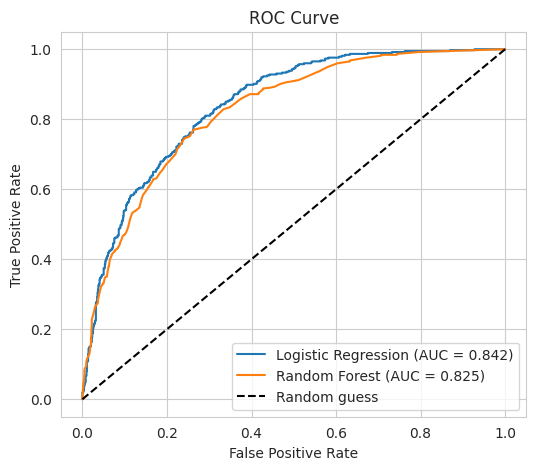

In [15]:
plt.figure(figsize=(6, 5))

for prob, name in [(lr_prob, "Logistic Regression"), (rf_prob, "Random Forest")]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, prob):.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 8. Which factors drive churn?

Random Forest gives feature importance scores for free — useful for business insight.

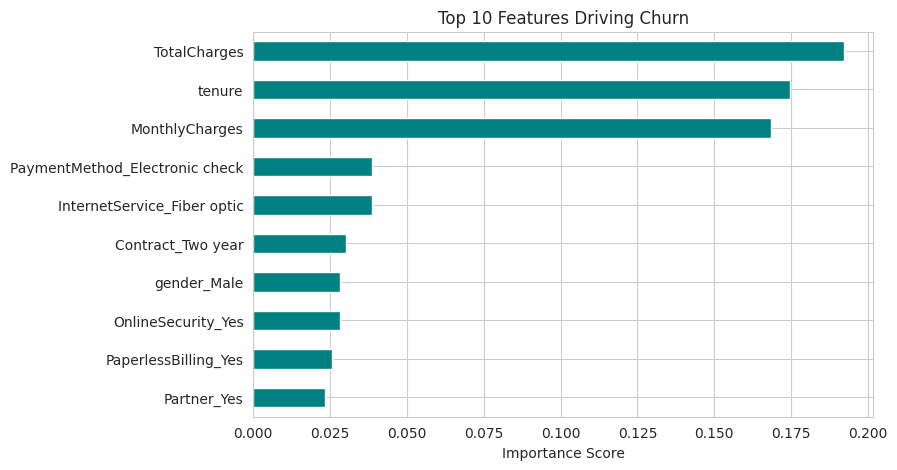

In [16]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 Features Driving Churn")
plt.xlabel("Importance Score")
plt.show()

`TotalCharges`, `tenure` and `MonthlyCharges` are the biggest drivers, along with contract type and internet service.

## 9. Quick prediction on one customer

Sanity check: feed one test customer into the model and compare with the actual label.

In [17]:
sample = X_test.iloc[[0]]
print("Model predicts :", "Churn" if rf.predict(sample)[0] == 1 else "Stay")
print("Actual         :", "Churn" if y_test.iloc[0] == 1 else "Stay")

Model predicts : Stay
Actual         : Stay


## 10. Conclusion

- Logistic Regression reached ~80% accuracy with ROC-AUC ~0.84 — a strong baseline.
- Random Forest was close, and its feature importance gave clear business insight.
- The main churn drivers are **tenure, monthly charges and contract type**.

**Possible improvements:** hyperparameter tuning (GridSearchCV), handling class imbalance with SMOTE, and trying XGBoost.